# data_analysis.py file Test with Data from Intel Device

In [ ]:
import data_analysis as da
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# file_path = "N:\\W26-S26 Baugh Lab Coop\\Measurement Data 3D1S FC\\"
file_path = "N:\\W26-S26 Baugh Lab Coop\\Measurement Data 3D1S Autotuning\\"

### Turn-on

In [ ]:
file_path_turnon = file_path + "Turnon.csv"
df = pd.read_csv(file_path_turnon)
Xdata = df["P0 (V)"].to_numpy()
TDdata = df["Triple Dot Voltage (V)"].to_numpy()
SETData = df["SET Voltage (V)"].to_numpy()

print("Triple Dot Turn on:")
TD_turnon = da.extract_turn_on_voltage(Xdata, TDdata)

# print("SET Turn on:")
# SET_turnon = da.extract_turn_on_voltage(Xdata, SETData)

### Pinch-Off Curves First Cooldown

In [ ]:
files = ["B0PO.csv", "B1PO.csv", "B2PO.csv", "B3PO.csv", "P0PO.csv", "P1PO.csv", "P2PO.csv"]
gate_types = ['Barrier', 'Barrier', 'Barrier', 'Barrier', 'Plunger', 'Plunger', 'Plunger']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[1]
    Xdata = df[name].to_numpy()
    TDdata = df["Triple Dot Voltage (V)"].to_numpy()*1e-7*1e9 #nA

    print(f"{gate_types[i]} pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, TDdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)

files = ["B20PO.csv", "B21PO.csv", "B20S_2.csv", "B21S_2.csv", "P20PO.csv"]
gate_types = ['Barrier', 'Barrier', 'Barrier', 'Barrier', 'Plunger']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[1]
    Xdata = df[name].to_numpy()
    SETdata = df["SET Voltage (V)"].to_numpy()*1e-8*1e9 #nA

    print(f"{gate_types[i]} pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, SETdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)

### Resweeping Barrier Gates

In [ ]:
files = ["B20S_2.csv", "B21S_2.csv"]
gate_types = ['Barrier', 'Barrier']
barrier_pinch_offs = []

for i, file in enumerate(files):
    file_path_bg = file_path + file
    df = pd.read_csv(file_path_bg)
    name = df.columns[1]
    Xdata = df[name].to_numpy()
    TDdata = df["SET Voltage (V)"].to_numpy()*1e-7*1e9 #nA
    nf = np.average(TDdata[-15:])

    print("Barrier gate Resweep:")
    voltage_window, pinch_off_fig = da.extract_pinch_off_curve_ranges(Xdata, TDdata, nf, gate_types[i])
    barrier_pinch_offs.append(voltage_window[0])
    display(pinch_off_fig)
    
print("Barrier pinch-off voltages:", barrier_pinch_offs)

### Pinch-off for Second Cooldown

In [ ]:
files = ["B0PO_2.csv", "B1PO_2.csv", "B2PO_2.csv", "B3PO_2.csv", "P0PO_2.csv", "P1PO_2.csv", "P2PO_2.csv"]  # "AC0PO.csv", "AC1PO.csv", "B0PO_2.csv", "B1PO_2.csv", "B2PO_2.csv", "B3PO_2.csv", "P0PO_2.csv", "P1PO_2.csv", "P2PO_2.csv"
gate_types = ['Barrier', 'Barrier', 'Barrier', 'Barrier', 'Plunger', 'Plunger', 'Plunger']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[1]
    Xdata = df[name].to_numpy()
    TDdata = df["Triple Dot Signal (V)"].to_numpy()*1e-8*1e9 #nA


    print(f"{gate_types[i]} pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, TDdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)


files = ["AC3PO.csv", "B20PO_2.csv", "B21PO_2.csv", "P20PO_2.csv"]   # "AC2PO.csv", "AC3PO.csv", "B20PO_2.csv", "B21PO_2.csv", "P20PO_2.csv"
gate_types = ['Accumulation', 'Barrier', 'Barrier', 'Plunger']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[1]
    Xdata = df[name].to_numpy()
    SETdata = df["SET Signal (V)"].to_numpy()*1e-8*1e9 #nA

    print(f"{gate_types[i]} pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, SETdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)

### Pinch-Off for Autotuning Collected Data

In [ ]:
files = [
        "Middle Dot Plunger_Pinch_Off_2026-06-14_02-11-11.csv",
         "Left Dot Plunger_Pinch_Off_2026-06-14_02-06-49.csv",
         "Left Dot Accumulation Gate_Pinch_Off_2026-06-15_10-17-55.csv",
         "Right Dot Plunger_Pinch_Off_2026-06-14_02-15-32.csv",
         "Right Dot Accumulation Gate_Pinch_Off_2026-06-14_22-27-24.csv"
         ]
gate_types = ['Plunger', 'Plunger', 'Accumulation', 'Plunger', 'Accumulation']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[0]
    Xdata = df[name].to_numpy()
    name = df.columns[-2]
    TDdata = df[name].to_numpy()*1e-8*1e9 #nA

    print(f"TD {gate_types[i]} Gate pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, TDdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)

files = [
         "Left Sensor Accumulation Gate and Flanking Gates_Pinch_Off_2026-06-14_02-02-27.csv",
         "Sensor Plunger_Pinch_Off_2026-06-14_22-50-20.csv",
         "Right Sensor Accumulation Gate_Pinch_Off_2026-06-14_02-00-17.csv"
         ]
gate_types = ['Accumulation', 'Plunger', 'Accumulation']

for i, file in enumerate(files):
    file_path_po = file_path + file
    df = pd.read_csv(file_path_po)
    name = df.columns[0]
    Xdata = df[name].to_numpy()
    name = df.columns[-1]
    SETdata = df[name].to_numpy()*1e-8*1e9 #nA

    print(f"SET {gate_types[i]} Gate pinch-off:")
    voltage_window = da.extract_pinch_off_curve_ranges(Xdata, SETdata, 1e-3, gate_types[i])
    print(f"Pinch-Off: {voltage_window[0]}, Saturation: {voltage_window[1]}")
    # display(fig)

### Barrier-Barrier Scan for First Cooldown

In [ ]:
file_path_bbs = file_path + "Left Sensor Barrier Gate_Right Sensor Barrier Gate_Scan_2026-06-12_08-22-11.csv"
df = pd.read_csv(file_path_bbs)
lbdata = df["spi_rack.module1.dac8.voltage"].to_numpy()
rbdata = df["spi_rack.module1.dac7.voltage"].to_numpy()
TDdata = df["agilent_left.volt"].to_numpy()*1e-8*1e9 #nA
SETdata = df["agilent_right.volt"].to_numpy()*1e-8*1e9 #nA

print("B20-B21 Sweep:")
for i in range(1):
    best_point, working_points, perp_traces = da.extract_working_point(lbdata, rbdata, SETdata, ["B20", "B21"], 'SET', barrier_pinch_offs=(0.85, 0.85), debug=False, plot_results=True)
    print(best_point)

### Barrier-Barrier Scan for Autotuning

[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


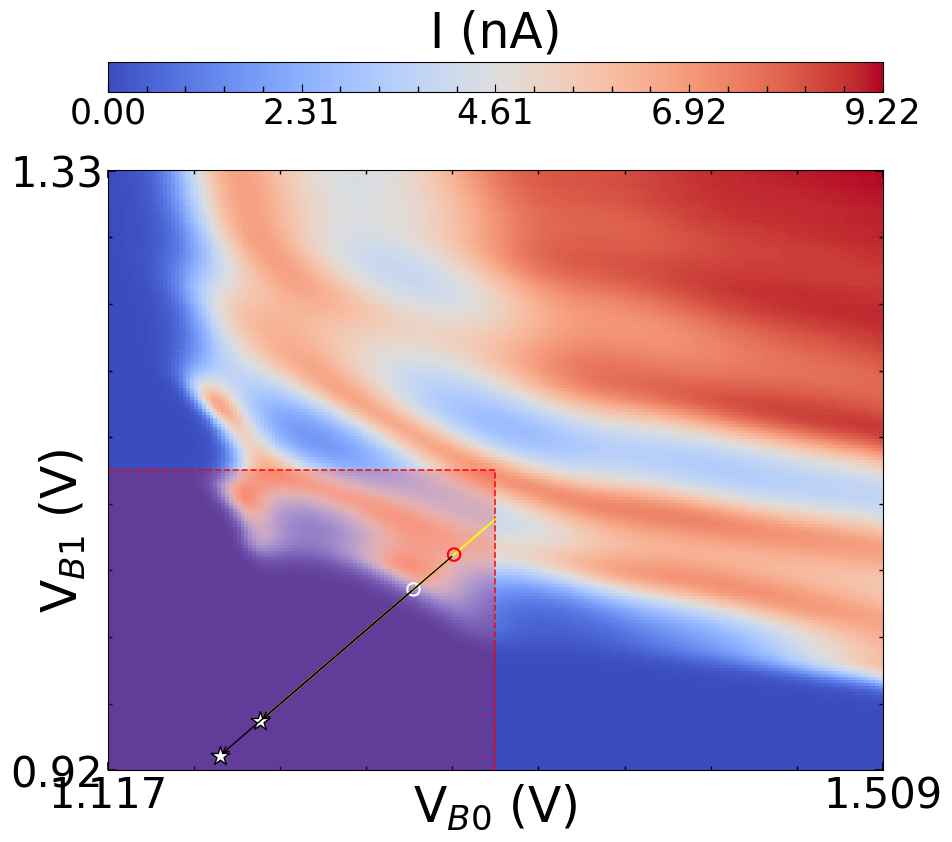

(1.1736442220990118, 0.9301590040848318)
[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


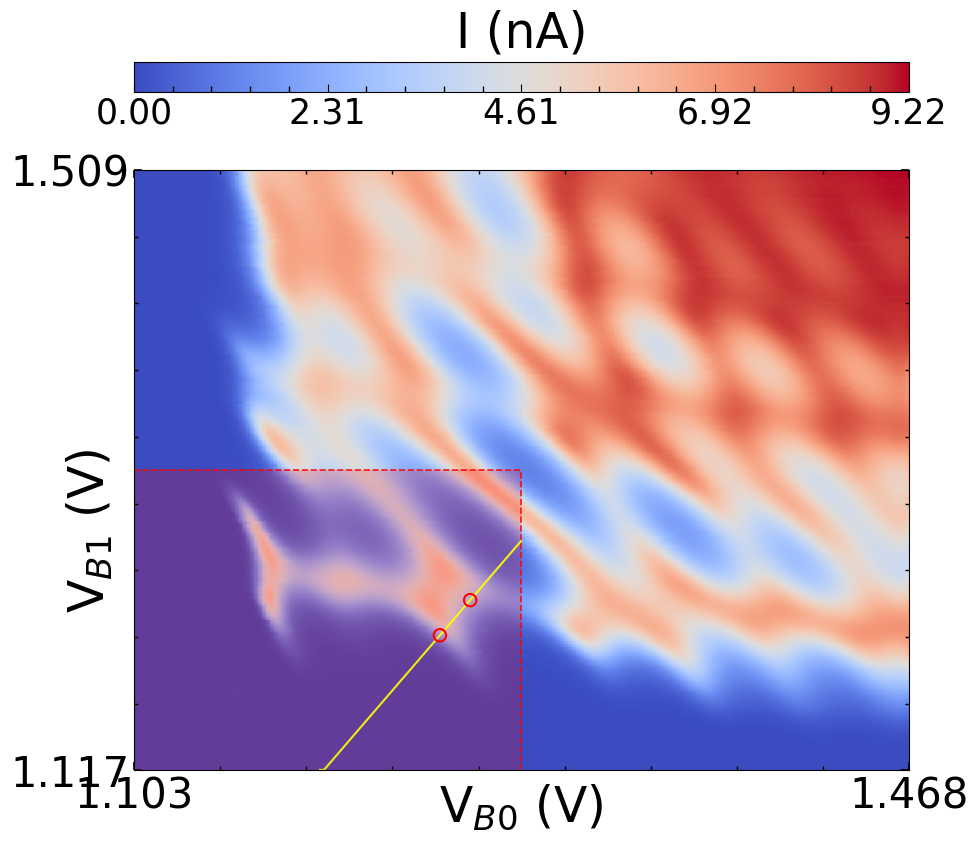

(1.035450896345863, 1.177461268331399)
[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


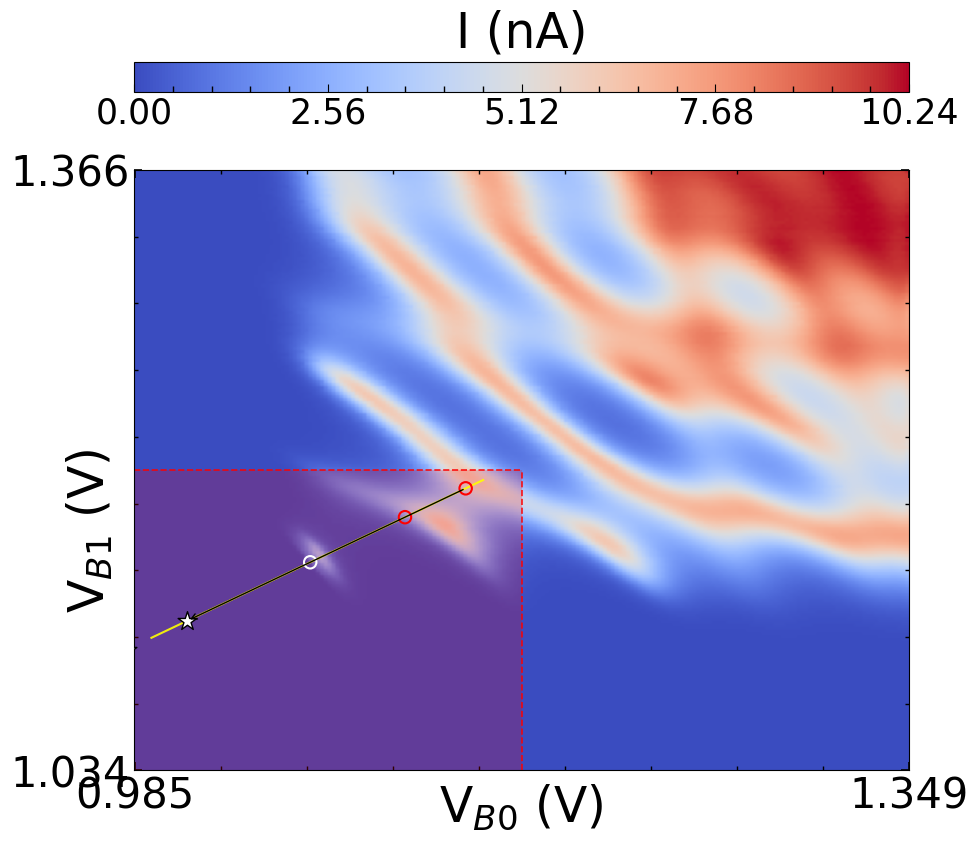

(0.9363864349441465, 1.0759202810321147)
[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


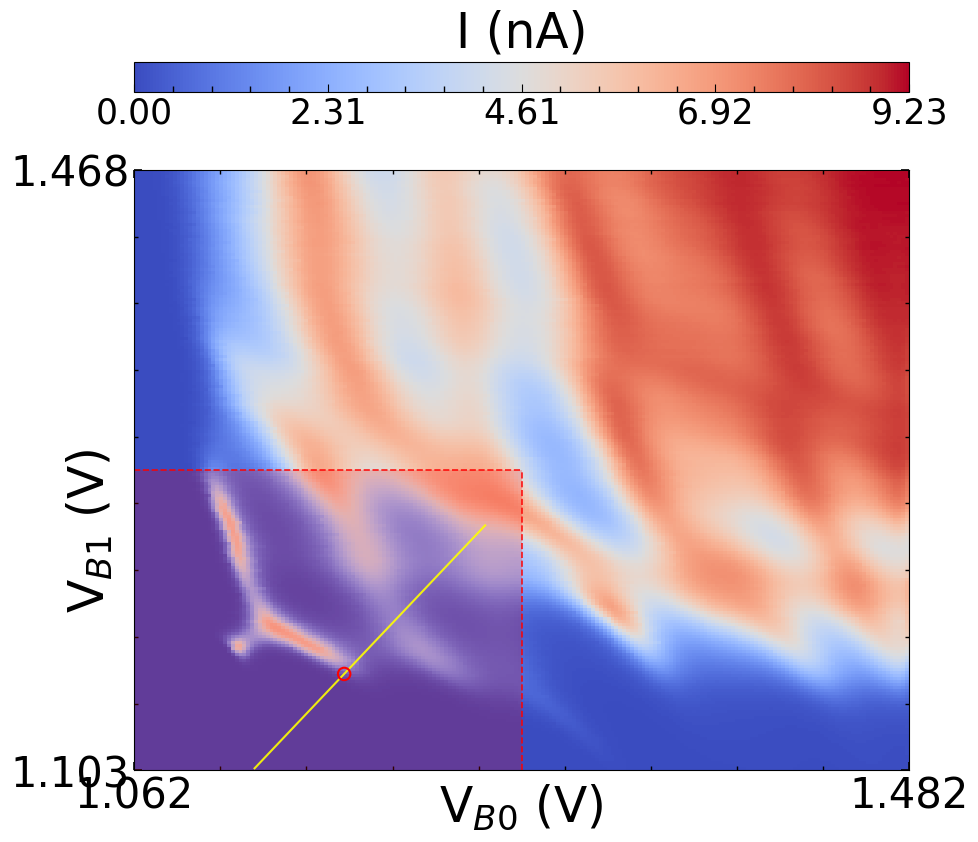

(1.046048661297587, 1.070911181966229)
[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


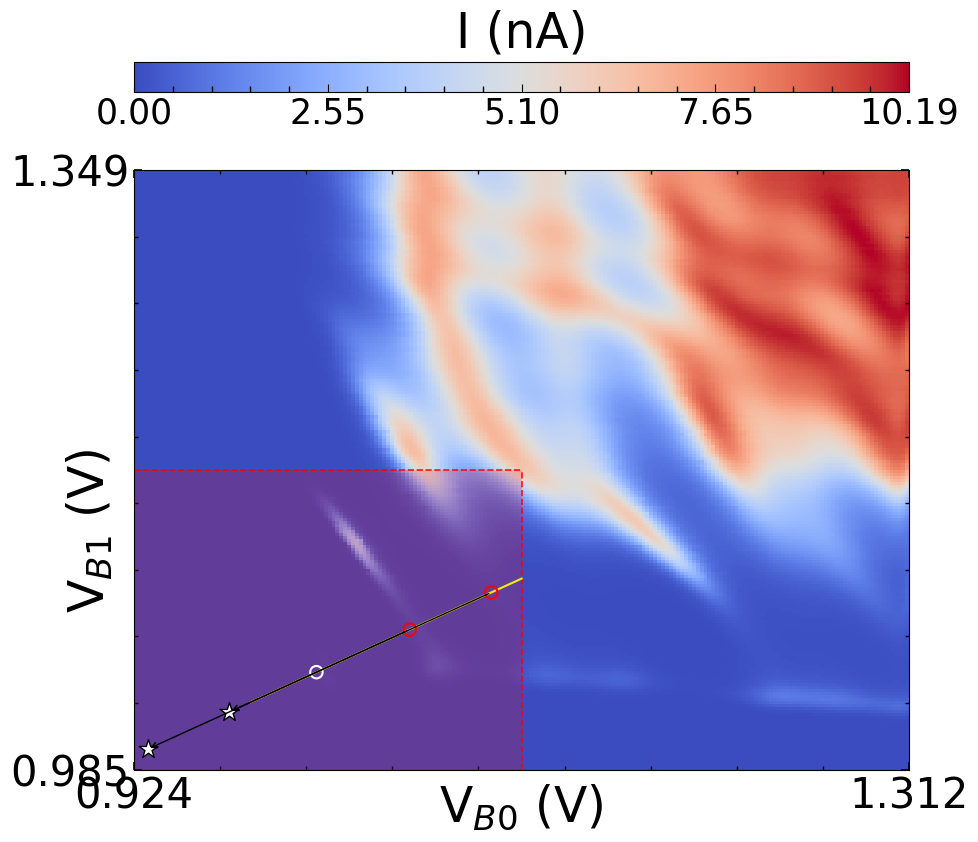

(0.8840267393649278, 0.9716041113188372)
[['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac5.voltage', 'spi_rack.module1.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module2.dac9.voltage', 'spi_rack.module2.dac5.voltage'], ['spi_rack.module1.dac5.voltage', 'spi_rack.module2.dac10.voltage']]


c:\Users\dhruv\GitHub\QuantumDotControl\src\data_analysis.py:1108: PeakPropertyWarning: some peaks have a prominence of 0
  prom = signal.peak_prominences(trace_smooth, peak_idx)[0]


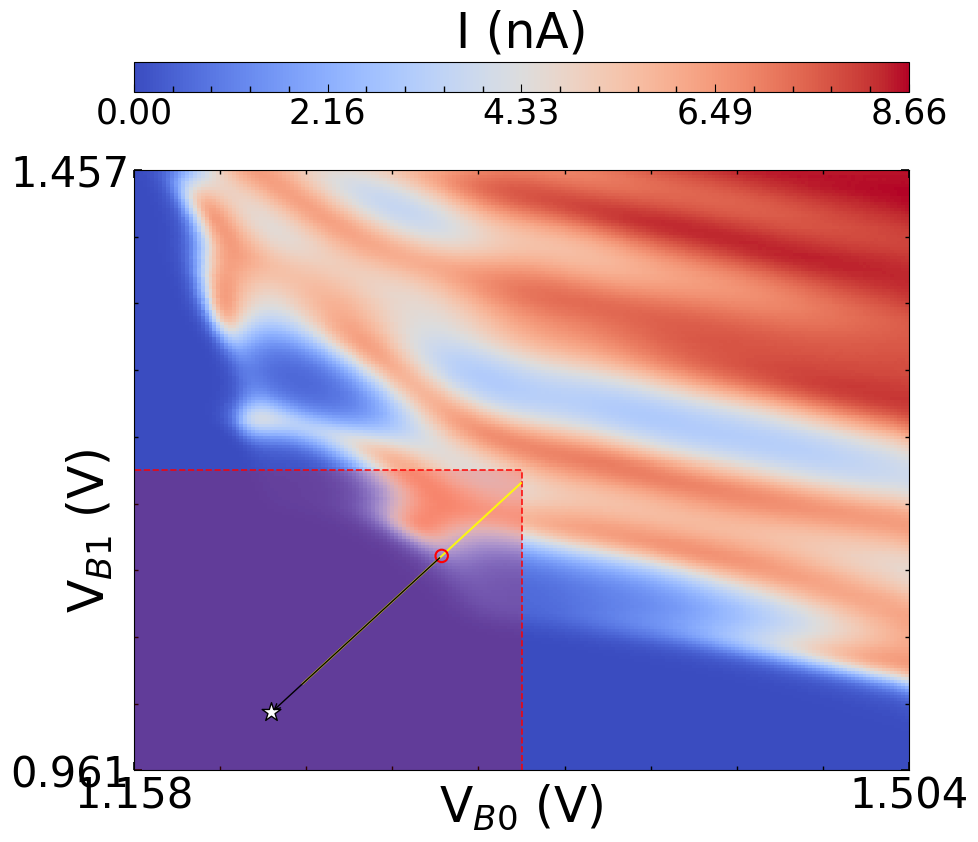

(1.2099456564039857, 1.0144217788928576)


In [ ]:
files = {
         "Dot 2-3 Barrier Gate_Right Barrier Gate_Scan_2026-06-14_08-45-06.csv": ["spi_rack.module1.dac5.voltage", "spi_rack.module2.dac10.voltage"],
         "Dot 1-2 Barrier Gate_Dot 2-3 Barrier Gate_Scan_2026-06-14_05-42-36.csv": ["spi_rack.module2.dac5.voltage", "spi_rack.module1.dac5.voltage"],
         "Dot 1-2 Barrier Gate_Dot 2-3 Barrier Gate_Scan_2026-06-10_06-40-41.csv": ["spi_rack.module2.dac5.voltage", "spi_rack.module1.dac5.voltage"],
         "Left Barrier Gate_Dot 1-2 Barrier Gate_Scan_2026-06-14_02-40-12.csv": ["spi_rack.module2.dac9.voltage", "spi_rack.module2.dac5.voltage"],
         "Left Barrier Gate_Dot 1-2 Barrier Gate_Scan_2026-06-10_03-39-56.csv": ["spi_rack.module2.dac9.voltage", "spi_rack.module2.dac5.voltage"],
         "Dot 2-3 Barrier Gate_Right Barrier Gate_Scan_2026-06-15_17-02-57.csv": ["spi_rack.module1.dac5.voltage", "spi_rack.module2.dac10.voltage"]
}

bpo = [(1.1173657230878, 0.920039897982374), (1.10292669377035, 1.1173657230878), (0.984523219674789, 1.03446691590468), (1.06201611070427, 1.10292669377035), (0.924152065222287, 0.984523219674789), (1.15827630615388, 0.960978258124794)]

for i, file in enumerate(files):
    file_path_bbs = file_path + file
    df = pd.read_csv(file_path_bbs)
    lbdata = df[list(files.values())[i][0]].to_numpy()
    rbdata = df[list(files.values())[i][1]].to_numpy()
    TDdata = df["agilent_left.volt"].to_numpy()*1e-8*1e9 #nA
    SETdata = df["agilent_right.volt"].to_numpy()*1e-8*1e9 #nA

    # print("B20-B21 Sweep:")
    best_point, working_points, perp_traces = da.extract_working_point(lbdata, rbdata, TDdata, ["B0", "B1"], 'Triple Dot', barrier_pinch_offs=bpo[i], debug=False)
    print(best_point)

### Coulomb Oscillations: Finding max conductance pts

In [ ]:
file_path_co = file_path + "P20S.csv"
df = pd.read_csv(file_path_co)
Xdata = df["P20 (V)"].to_numpy()
SETdata = df["SET Voltage (V)"].to_numpy()*1e-7*1e9 #nA

best_pts, _ = da.extract_max_conductance_points(Xdata, SETdata)
print(best_pts)

### Dot - Lead Tuning

In [ ]:
file_path_dl = file_path + "P0B0S_BT.csv" # P2B3S
df = pd.read_csv(file_path_dl)
Xdata = df["P0 (V)"].to_numpy()
Ydata = df["B0 (V)"].to_numpy()
SETdata = df["SET Signal (V)"].to_numpy()*1e-8*1e9 #nA

best_sens_pts_list, all_sens_pts_list, set_point = da.extract_tunnel_barrier_latching(Xdata, Ydata, SETdata)
print(set_point)

### Plunger Gate Countersweeping

In [ ]:
file_path_cs = file_path + "P0P20CS.csv"
df = pd.read_csv(file_path_cs)
Xdata = df["P0 (V)"].to_numpy()
SETdata = df["SET Voltage (V)"].to_numpy()*1e-7*1e9 #nA
der = np.gradient(SETdata, Xdata)
height = abs(der).max()*0.81

best_pts, conductance = da.extract_max_conductance_points(Xdata, SETdata, peak_height=[height, height])
print(conductance)

### Charge Transitions Confirmation for Autotuning Code

In [ ]:
files = [
         "Left Dot Plunger_Sweep_2026-06-20_19-05-33.csv",
         "Left Dot Plunger_Sweep_2026-06-20_20-24-58.csv",
         "Left Dot Plunger_Sweep_2026-06-21_15-07-12.csv",
         "Middle Dot Plunger_Sweep_2026-06-20_19-11-10.csv",
         "Middle Dot Plunger_Sweep_2026-06-20_20-30-34.csv",
         "Middle Dot Plunger_Sweep_2026-06-21_15-12-48.csv",
         "Right Dot Plunger_Sweep_2026-06-20_20-36-11.csv",
         "Right Dot Plunger_Sweep_2026-06-21_15-18-25.csv",
         "Right Dot Plunger_Sweep_2026-06-20_19-16-46.csv"
         ]

for file in files:
    file_path_ct = file_path + file
    df = pd.read_csv(file_path_ct)
    Xgate = df.columns[0]
    Xdata = df[Xgate].to_numpy()
    SETgate = df.columns[-1]
    SETdata = df[SETgate].to_numpy()*1e-8*1e9 #nA

    print("#-----------------------------------------------------------------------------")
    best_voltage = da.extract_charge_transitions(Xdata, SETdata)
    print(best_voltage)